In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are now expected on the local filesystem. Set LOCAL_DATA_DIR
# (or rely on the notebook's working directory) to point to the folder that
# contains data.csv, predict.csv, etc.

import os
from pathlib import Path

LOCAL_DATA_DIR = Path(os.environ.get("LOCAL_DATA_DIR", Path.cwd())).resolve() / "data"
print(f"LOCAL_DATA_DIR set to {LOCAL_DATA_DIR}")

LOCAL_DATA_DIR set to /home/fredc/NTU-DSAI/kaggle-lr/data


In [2]:
## Starter Code for Building Baseball Win Prediction Model

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Load the pre-processed datasets from the directory pointed to by LOCAL_DATA_DIR
DATA_DIR = LOCAL_DATA_DIR  # defined in the previous cell
print(f"Loading datasets from {DATA_DIR}")

data_df = pd.read_csv(DATA_DIR / "data.csv")
predict_df = pd.read_csv(DATA_DIR / "predict.csv")

# Display basic information about the datasets
print(f"Data set shape: {data_df.shape}")
print(f"Predict set shape: {predict_df.shape}")

Loading datasets from /home/fredc/NTU-DSAI/kaggle-lr/data
Data set shape: (1812, 51)
Predict set shape: (453, 45)


In [3]:
# Add a compact set of baseball features that usually improves MAE without overcomplicating the model

def safe_divide(num, den):
    return np.where(den != 0, num / den, 0)

def get_col(df, col_name):
    if col_name in df.columns:
        return df[col_name]
    return pd.Series(0, index=df.index, dtype=float)

for df in (data_df, predict_df):
    runs         = get_col(df, 'R')
    runs_allowed = get_col(df, 'RA')
    games        = get_col(df, 'G')
    at_bats      = get_col(df, 'AB')
    hits         = get_col(df, 'H')
    doubles      = get_col(df, '2B')
    triples      = get_col(df, '3B')
    home_runs    = get_col(df, 'HR')
    walks        = get_col(df, 'BB')
    strikeouts   = get_col(df, 'SO')
    steals       = get_col(df, 'SB')
    caught_stealing = get_col(df, 'CS')
    hits_allowed    = get_col(df, 'HA')
    walks_allowed   = get_col(df, 'BBA')
    ks_allowed      = get_col(df, 'SOA')
    hr_allowed      = get_col(df, 'HRA')
    innings_outs    = get_col(df, 'IPouts')
    innings_pitched = safe_divide(innings_outs, 3)
    complete_games  = get_col(df, 'CG')
    shutouts        = get_col(df, 'SHO')
    errors          = get_col(df, 'E')
    double_plays    = get_col(df, 'DP')
    sac_flies       = get_col(df, 'SF')
    bpf             = get_col(df, 'BPF')
    ppf             = get_col(df, 'PPF')

    # ── Existing features ────────────────────────────────────────────────────
    df['run_diff']          = runs - runs_allowed
    df['run_diff_per_game'] = safe_divide(df['run_diff'], games)
    df['win_expectancy']    = safe_divide(runs ** 2, runs ** 2 + runs_allowed ** 2)
    df['hr_rate']           = safe_divide(home_runs, at_bats)
    df['bb_rate']           = safe_divide(walks, at_bats)
    df['so_rate']           = safe_divide(strikeouts, at_bats)
    df['hit_rate']          = safe_divide(hits, at_bats)
    df['extra_base_hits']   = doubles + triples + home_runs
    df['xbh_rate']          = safe_divide(df['extra_base_hits'], hits)
    df['steal_value']       = steals - caught_stealing
    df['baserunning_value'] = safe_divide(df['steal_value'], games)
    df['pitching_whip_proxy'] = safe_divide(hits_allowed + walks_allowed, innings_pitched)

    # ── Pythagorean expectation (PythagoPat, dynamic exponent ~1.83) ─────────
    pyth_exp                  = safe_divide((runs + runs_allowed) ** 0.285, 1)
    df['win_exp_pythagorean'] = safe_divide(runs ** pyth_exp,
                                             runs ** pyth_exp + runs_allowed ** pyth_exp)

    # ── Batting quality ───────────────────────────────────────────────────────
    df['obp_proxy']     = safe_divide(hits + walks, at_bats + walks)   # on-base proxy
    df['iso']           = safe_divide(doubles + 2 * triples + 3 * home_runs, at_bats)  # isolated power
    df['contact_rate']  = 1 - safe_divide(strikeouts, at_bats)         # avoid strikeouts
    df['babip']         = safe_divide(hits - home_runs,
                                      at_bats - strikeouts - home_runs + sac_flies)  # luck-neutral avg

    # ── Defense-independent pitching ─────────────────────────────────────────
    df['fip_proxy']  = safe_divide(13 * hr_allowed + 3 * walks_allowed - 2 * ks_allowed,
                                   innings_pitched)
    df['k_bb_ratio'] = safe_divide(ks_allowed, walks_allowed)          # strikeout-to-walk

    # ── Park-factor adjusted run differential ────────────────────────────────
    park_adj_r              = safe_divide(runs,         bpf / 100)
    park_adj_ra             = safe_divide(runs_allowed, ppf / 100)
    df['park_adj_run_diff'] = park_adj_r - park_adj_ra

    # ── Pitching / fielding efficiency rates ─────────────────────────────────
    df['cg_rate']  = safe_divide(complete_games, games)
    df['sho_rate'] = safe_divide(shutouts,       games)
    df['dp_rate']  = safe_divide(double_plays,   games)
    df['e_rate']   = safe_divide(errors,         games)

# Select the base features plus engineered features that exist in both train and prediction data
base_features = [
    # Basic Statistics
    'G', 'R', 'AB', 'H', '2B', '3B', 'HR', 'BB', 'SO', 'SB', 'CS', 'HBP', 'SF',
    'RA', 'ER', 'CG', 'SHO', 'SV', 'IPouts', 'HA', 'HRA', 'BBA', 'SOA',
    'E', 'DP', 'FP', 'attendance', 'BPF', 'PPF',

    # Derived Features already present in the dataset
    'R_per_game', 'RA_per_game', 'mlb_rpg',

    # Era Indicators
    'era_1', 'era_2', 'era_3', 'era_4', 'era_5', 'era_6', 'era_7', 'era_8',

    # Decade Indicators
    'decade_1910', 'decade_1920', 'decade_1930', 'decade_1940', 'decade_1950',
    'decade_1960', 'decade_1970', 'decade_1980', 'decade_1990', 'decade_2000', 'decade_2010'
]

engineered_features = [
    # Existing
    'run_diff', 'run_diff_per_game', 'win_expectancy',
    'hr_rate', 'bb_rate', 'so_rate', 'hit_rate',
    'extra_base_hits', 'xbh_rate',
    'steal_value', 'baserunning_value', 'pitching_whip_proxy',
    # New
    'win_exp_pythagorean',
    'obp_proxy', 'iso', 'contact_rate', 'babip',
    'fip_proxy', 'k_bb_ratio',
    'park_adj_run_diff',
    'cg_rate', 'sho_rate', 'dp_rate', 'e_rate',
]

candidate_features = base_features + engineered_features
available_features = [col for col in candidate_features if col in data_df.columns and col in predict_df.columns]
print(f"Number of available features: {len(available_features)}")

# Separate features and target variable
X = data_df[available_features]
y = data_df['W']

# Perform the split (adjust test_size / random_state as needed)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Number of available features: 67


In [4]:
# Scale features
# Identify columns to exclude from scaling (one-hot encoded and label columns)
one_hot_cols = [col for col in X_train.columns if col.startswith(('era_', 'decade_'))]
other_cols = [col for col in X_train.columns if col not in one_hot_cols]

# Scale only non-one-hot features
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[other_cols] = scaler.fit_transform(X_train[other_cols])
X_test_scaled[other_cols] = scaler.transform(X_test[other_cols])

In [5]:
# ── Pipeline Infrastructure ───────────────────────────────────────────────────
# Centralised helpers: adding a new model is a 2-line operation (train + register).
import os
from datetime import datetime

COMPETITION_NAME = "sctpdsai-m-3-ds-2-f-coaching-money-ball-analytics"

models_registry = {}  # name → {model, train_mae, test_mae, test_rmse, test_r2, test_preds, train_preds, ...}


def evaluate_model(model):
    """Return train/test metrics and raw predictions for a fitted model."""
    train_preds = model.predict(X_train_scaled)
    test_preds  = model.predict(X_test_scaled)
    return dict(
        train_preds = train_preds,
        test_preds  = test_preds,
        train_mae   = mean_absolute_error(y_train, train_preds),
        test_mae    = mean_absolute_error(y_test,  test_preds),
        test_rmse   = np.sqrt(mean_squared_error(y_test, test_preds)),
        test_r2     = r2_score(y_test, test_preds),
    )


def register_model(name, model, **meta):
    """Evaluate a fitted model and add it to the registry. Returns metrics dict."""
    metrics = evaluate_model(model)
    models_registry[name] = {"model": model, **metrics, **meta}
    print(f"  {name:30s}  train MAE={metrics['train_mae']:.4f}  "
          f"test MAE={metrics['test_mae']:.4f}  R²={metrics['test_r2']:.4f}")
    return metrics


def compare_models():
    """Print a leaderboard of all registered models sorted by test MAE."""
    rows = {
        name: {
            "Train MAE": cfg["train_mae"],
            "Test MAE":  cfg["test_mae"],
            "Test RMSE": cfg["test_rmse"],
            "Test R²":   cfg["test_r2"],
        }
        for name, cfg in models_registry.items()
    }
    df = pd.DataFrame(rows).T.sort_values("Test MAE")
    print(df.to_string(float_format="{:.4f}".format))
    return df


def generate_submission(model_name):
    """Run inference on predict.csv and write a timestamped submission CSV. Returns filepath."""
    if model_name not in models_registry:
        raise ValueError(f"'{model_name}' not in registry. Available: {list(models_registry)}")
    cfg = models_registry[model_name]

    predict_features = predict_df[available_features].copy()
    predict_scaled   = predict_features.copy()
    predict_scaled[other_cols] = scaler.transform(predict_features[other_cols])
    preds = cfg["model"].predict(predict_scaled)

    ts       = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"submission_{model_name}_{ts}.csv"
    pd.DataFrame({"ID": predict_df["ID"], "W": preds}).to_csv(filename, index=False)
    print(f"  saved → {filename}  (test MAE={cfg['test_mae']:.4f})")
    return filename


def submit_to_kaggle(filepath, message):
    """Upload a submission CSV to Kaggle."""
    cmd = f'kaggle competitions submit -c {COMPETITION_NAME} -f "{filepath}" -m "{message}"'
    os.system(cmd)


print("Pipeline infrastructure ready.")

Pipeline infrastructure ready.


In [6]:
# ── Model: Linear Regression (baseline) ──────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
register_model("LinearRegression", lr, version="baseline")

  LinearRegression                train MAE=2.5939  test MAE=2.8281  R²=0.9221


{'train_preds': array([78.41915871, 73.65460936, 85.43196254, ..., 93.72247545,
        76.786141  , 95.98847407]),
 'test_preds': array([ 76.70764639,  76.51358234,  81.82641265,  84.79826259,
         78.90989409,  63.76601481,  78.7299326 ,  58.52881071,
         61.52533899,  61.94659978,  80.43089838,  79.75671435,
         93.41787561,  80.83554109,  76.70739838,  98.95241877,
         88.93996821,  92.87891436,  60.26450379,  92.6711534 ,
         93.30511948, 101.10210946,  68.60233993,  84.75812414,
         81.79217741, 103.19610725,  59.46247909,  67.38100713,
         71.51438227,  60.74238474,  90.61697903,  95.95997404,
         68.81370351,  84.50561832,  80.1655274 ,  76.97552198,
         47.74128294,  86.011426  ,  90.72679593,  73.26757935,
         97.72290835,  53.77096198,  92.74230288,  84.23597394,
         93.41351356,  87.25376522,  88.49322104,  77.60735299,
         55.07423007,  72.53124631,  89.51410855,  89.80283368,
         62.14178542,  92.91560992,  8

In [7]:
# ── Model: RidgeCV ────────────────────────────────────────────────────────────
from sklearn.linear_model import RidgeCV

ridge_cv = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0, 500.0, 1000.0],
                   cv=5, scoring="neg_mean_absolute_error")
ridge_cv.fit(X_train_scaled, y_train)
print(f"RidgeCV best alpha: {ridge_cv.alpha_:.4f}")
register_model("RidgeCV", ridge_cv, alpha=ridge_cv.alpha_, version="v3_regularized")

RidgeCV best alpha: 1.0000
  RidgeCV                         train MAE=2.6035  test MAE=2.8177  R²=0.9219


{'train_preds': array([78.64803532, 73.61990288, 85.61249231, ..., 93.61019196,
        76.68102284, 95.7196092 ]),
 'test_preds': array([ 76.67599868,  76.54433302,  82.32372998,  85.20663704,
         78.83489224,  63.97328433,  78.47412387,  58.54919649,
         61.81725058,  62.25999934,  79.70904879,  79.5033344 ,
         93.37794066,  81.02379552,  77.11237333,  98.90089577,
         88.7983499 ,  92.69959199,  60.18561251,  92.54379512,
         93.03924395, 100.99839871,  68.94707106,  85.09739756,
         81.65805262, 103.21493837,  59.87648241,  67.49128127,
         71.27664544,  60.64131327,  90.49006185,  96.00551516,
         68.93189749,  84.55361667,  80.39300796,  77.20358465,
         48.20861432,  85.90758232,  90.80724377,  73.00697805,
         97.74351479,  53.65460653,  92.91664686,  84.33847953,
         93.18878395,  86.99257541,  88.41597357,  77.62794981,
         55.53081456,  72.94733248,  88.98274499,  90.18754485,
         62.24958597,  92.77604827,  8

In [8]:
# ── Model: ElasticNetCV (L1 + L2) ────────────────────────────────────────────
from sklearn.linear_model import ElasticNetCV

enet_cv = ElasticNetCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
                       l1_ratio=[0.1, 0.25, 0.5, 0.75, 0.9],
                       cv=5, max_iter=10000)
enet_cv.fit(X_train_scaled, y_train)
print(f"ElasticNetCV best alpha: {enet_cv.alpha_:.4f}  l1_ratio: {enet_cv.l1_ratio_:.2f}")
register_model("ElasticNetCV", enet_cv, alpha=enet_cv.alpha_, l1_ratio=enet_cv.l1_ratio_, version="v5_elasticnet")

/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.483e+02, tolerance: 2.051e+01
  model = cd_fast.enet_coordinate_descent_gram(
/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.255e+03, tolerance: 2.051e+01
  model = cd_fast.enet_coordinate_descent_gram(
/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or conside

/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.371e+03, tolerance: 2.050e+01
  model = cd_fast.enet_coordinate_descent_gram(
/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.570e+03, tolerance: 1.994e+01
  model = cd_fast.enet_coordinate_descent_gram(
/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or conside

/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.202e+01, tolerance: 2.005e+01
  model = cd_fast.enet_coordinate_descent_gram(
/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.500e+03, tolerance: 2.005e+01
  model = cd_fast.enet_coordinate_descent_gram(
/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or conside

/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.716e+01, tolerance: 2.046e+01
  model = cd_fast.enet_coordinate_descent_gram(
/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.270e+03, tolerance: 2.046e+01
  model = cd_fast.enet_coordinate_descent_gram(
/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or conside

/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.687e+01, tolerance: 2.051e+01
  model = cd_fast.enet_coordinate_descent_gram(
/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.622e+03, tolerance: 2.051e+01
  model = cd_fast.enet_coordinate_descent_gram(
/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or conside

/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.524e+03, tolerance: 1.994e+01
  model = cd_fast.enet_coordinate_descent_gram(
/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.128e+01, tolerance: 2.051e+01
  model = cd_fast.enet_coordinate_descent_gram(
/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or conside

ElasticNetCV best alpha: 0.0100  l1_ratio: 0.90
  ElasticNetCV                    train MAE=2.6280  test MAE=2.8205  R²=0.9218


/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.636e+03, tolerance: 1.994e+01
  model = cd_fast.enet_coordinate_descent_gram(


{'train_preds': array([79.48377713, 73.42982162, 85.57710694, ..., 93.3334667 ,
        76.8224105 , 95.48809274]),
 'test_preds': array([ 76.09691196,  76.52827252,  82.73744192,  85.27572162,
         78.96041152,  64.0812687 ,  78.40436576,  58.93974559,
         61.91967089,  63.01353834,  79.17049905,  78.8493913 ,
         92.80748268,  80.81015225,  77.12732364,  98.96091318,
         88.99199673,  92.63109409,  60.32279053,  92.85570033,
         93.36211826, 101.39539189,  69.16127958,  84.89038563,
         82.34958283, 101.99671181,  60.01996843,  67.44680251,
         71.21397096,  60.25580805,  90.51740832,  96.21146781,
         68.89223779,  84.84631258,  80.57383364,  77.11337093,
         48.74790106,  85.57777631,  90.82855123,  73.00599529,
         97.9776833 ,  53.85735   ,  93.141905  ,  84.2929525 ,
         92.65204941,  86.95893206,  88.21160825,  77.37284603,
         55.74164224,  73.25415436,  88.61641858,  90.46727093,
         62.02752746,  92.7121049 ,  8

In [9]:
# ── Model: LassoCV (L1) ───────────────────────────────────────────────────────
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
                   cv=5, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)
print(f"LassoCV best alpha: {lasso_cv.alpha_:.4f}")
register_model("LassoCV", lasso_cv, alpha=lasso_cv.alpha_, version="v4_l1")

/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.195e+01, tolerance: 2.051e+01
  model = cd_fast.enet_coordinate_descent_gram(
/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.786e+03, tolerance: 2.051e+01
  model = cd_fast.enet_coordinate_descent_gram(
/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or conside

/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.716e+02, tolerance: 2.005e+01
  model = cd_fast.enet_coordinate_descent_gram(
/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.255e+03, tolerance: 2.005e+01
  model = cd_fast.enet_coordinate_descent_gram(
/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or conside

/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.703e+03, tolerance: 1.994e+01
  model = cd_fast.enet_coordinate_descent_gram(


LassoCV best alpha: 0.0100
  LassoCV                         train MAE=2.6269  test MAE=2.8178  R²=0.9219


{'train_preds': array([79.39174805, 73.43647669, 85.58567858, ..., 93.35058973,
        76.82012957, 95.49059417]),
 'test_preds': array([ 76.12763208,  76.49255961,  82.72524139,  85.1958516 ,
         78.9346084 ,  64.0771836 ,  78.43812375,  58.95127176,
         61.951747  ,  62.95607163,  79.18048643,  78.84599937,
         92.8643328 ,  80.82303715,  77.15315637,  99.00244826,
         88.99111671,  92.6510141 ,  60.33434136,  92.86061636,
         93.33940882, 101.39583621,  69.17625648,  84.8991091 ,
         82.29835962, 101.99891669,  59.9461597 ,  67.48644986,
         71.23758068,  60.20502086,  90.52273469,  96.20295208,
         68.8577457 ,  84.8286931 ,  80.60522674,  77.12658382,
         48.61734157,  85.59786512,  90.84438549,  73.03864506,
         97.95156872,  53.79274982,  93.15450753,  84.24121139,
         92.71958449,  86.91789679,  88.20693254,  77.37065601,
         55.67541258,  73.23925277,  88.62230226,  90.4268441 ,
         62.03797887,  92.69896592,  8

In [ ]:
# ── Model: Random Forest (constrained) ───────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

# Tighter search space to combat overfitting on ~1450 training samples
param_dist = {
    'n_estimators':      [300, 500, 800],
    'max_depth':         [3, 5, 7, 10],       # shallow trees
    'min_samples_split': [10, 20, 40],         # require more samples to split
    'min_samples_leaf':  [5, 10, 20],          # larger leaf nodes
    'max_features':      ['sqrt', 0.3, 0.4],   # fewer features per split
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=40,
    cv=5,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
)
rf_search.fit(X_train_scaled, y_train)

best_rf = rf_search.best_estimator_
print(f'Best params: {rf_search.best_params_}')
register_model('RandomForest', best_rf, version='v7_rf_constrained', **rf_search.best_params_)

In [ ]:
# ── Model: Huber Regression (robust to outliers) ─────────────────────────────
from sklearn.linear_model import HuberRegressor
from sklearn.model_selection import GridSearchCV

# epsilon: threshold between quadratic (inlier) and linear (outlier) loss
# alpha:   L2 regularisation strength
param_grid = {
    'epsilon': [1.1, 1.35, 1.5, 1.75, 2.0],
    'alpha':   [0.0001, 0.001, 0.01, 0.1, 1.0],
}

huber_search = GridSearchCV(
    HuberRegressor(max_iter=200),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
)
huber_search.fit(X_train_scaled, y_train)

best_huber = huber_search.best_estimator_
print(f'Best params: {huber_search.best_params_}')
register_model('HuberRegression', best_huber, version='v8_huber', **huber_search.best_params_)

In [10]:
# ── Model Comparison ──────────────────────────────────────────────────────────
# Automatically includes every model in the registry — re-run after adding new models.
compare_models()

                  Train MAE  Test MAE  Test RMSE  Test R²
RidgeCV              2.6035    2.8177     3.5417   0.9219
LassoCV              2.6269    2.8178     3.5412   0.9219
ElasticNetCV         2.6280    2.8205     3.5434   0.9218
LinearRegression     2.5939    2.8281     3.5367   0.9221


,Train MAE,Test MAE,Test RMSE,Test R²
RidgeCV,2.603500,2.817668,3.541731,0.921877
LassoCV,2.626891,2.817846,3.541203,0.921900
ElasticNetCV,2.627959,2.820543,3.543442,0.921802
LinearRegression,2.593895,2.828052,3.536663,0.922101


In [11]:
# ── Feature Importance ────────────────────────────────────────────────────────
def show_feature_importance(model_name, top_n=10):
    """Print top-N features by absolute coefficient for any linear model."""
    model = models_registry[model_name]["model"]
    coefs = getattr(model, "coef_", None)
    if coefs is None:
        print(f"{model_name} does not expose coef_ — use a permutation importance approach instead.")
        return
    df = (pd.DataFrame({"Feature": X_train.columns, "Coefficient": coefs})
            .sort_values("Coefficient", key=abs, ascending=False)
            .head(top_n))
    print(f"Top {top_n} features — {model_name}:")
    print(df.to_string(index=False))

show_feature_importance("LinearRegression")

Top 10 features — LinearRegression:
            Feature  Coefficient
                  E   -18.125925
             e_rate    17.722062
                iso    14.396821
            hr_rate   -13.271817
pitching_whip_proxy    -9.427149
                 CG     9.069508
                 DP    -7.505269
            dp_rate     7.499528
                SHO     7.271667
           sho_rate    -6.728330


In [12]:
# ── Generate Submission CSVs ──────────────────────────────────────────────────
# Generates a timestamped CSV for every model in the registry — no manual updates needed.
print("Generating submission files...\n")
submission_files = {name: generate_submission(name) for name in models_registry}
print("\nAll files ready. Run the next cell to deploy the best model.")

Generating submission files...

  saved → submission_LinearRegression_20260327_203904.csv  (test MAE=2.8281)
  saved → submission_RidgeCV_20260327_203904.csv  (test MAE=2.8177)
  saved → submission_ElasticNetCV_20260327_203904.csv  (test MAE=2.8205)
  saved → submission_LassoCV_20260327_203904.csv  (test MAE=2.8178)

All files ready. Run the next cell to deploy the best model.


In [13]:
# ── Deploy to Kaggle ──────────────────────────────────────────────────────────
# Default: picks the model with the lowest test MAE.
# Override: set deploy_model = "ModelName" to choose manually.

deploy_model = min(models_registry, key=lambda n: models_registry[n]["test_mae"])
# deploy_model = "RidgeCV"   # ← uncomment to override

deploy_file = submission_files[deploy_model]
print(f"Deploying: {deploy_model}  (test MAE={models_registry[deploy_model]['test_mae']:.4f})")
print(f"File:      {deploy_file}\n")
submit_to_kaggle(deploy_file, message=f"Deploy {deploy_model}")

Deploying: RidgeCV  (test MAE=2.8177)
File:      submission_RidgeCV_20260327_203904.csv



  0%|          | 0.00/9.93k [00:00<?, ?B/s]

100%|██████████| 9.93k/9.93k [00:00<00:00, 11.1kB/s]


Successfully submitted to SCTPDSAI-M3-DS2F-Coaching-MoneyBall Analytics

In [14]:
# ── Verify Recent Submissions ─────────────────────────────────────────────────
os.system(f"kaggle competitions submissions -c {COMPETITION_NAME}")

fileName                                         date                        description                   status                     publicScore  privateScore  
-----------------------------------------------  --------------------------  ----------------------------  -------------------------  -----------  ------------  
submission_RidgeCV_20260327_203904.csv           2026-03-27 12:39:07.017000  Deploy RidgeCV                SubmissionStatus.PENDING                              
submission_RidgeCV_20260327_195055.csv           2026-03-27 11:50:56.737000  Deploy RidgeCV                SubmissionStatus.COMPLETE  3.04701                    
submission_RidgeCV_20260327_194712.csv           2026-03-27 11:48:11.030000  Deploy RidgeCV                SubmissionStatus.COMPLETE  3.04701                    
submission_RidgeCV_20260327_194712.csv           2026-03-27 11:47:14.033000  Deploy RidgeCV                SubmissionStatus.COMPLETE  3.04701                    
submission_RidgeCV_20260327_

0

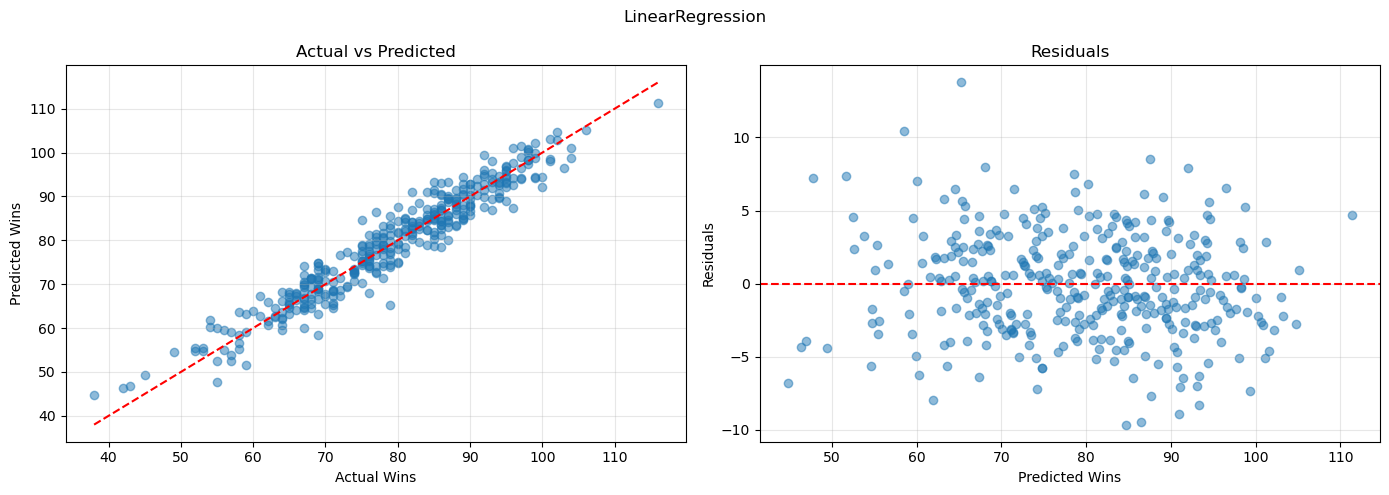

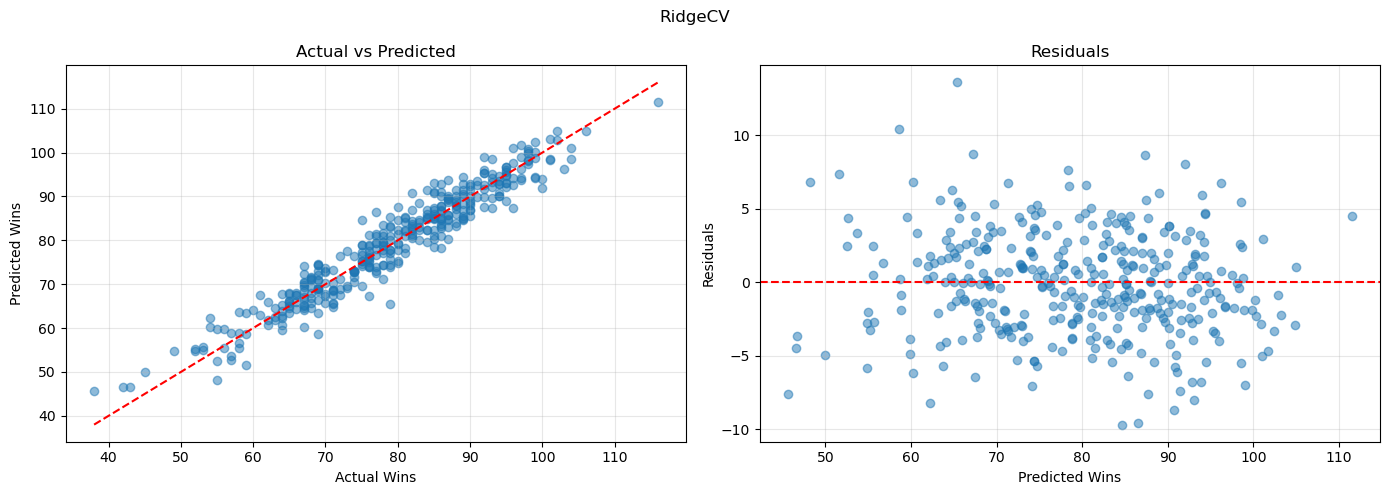

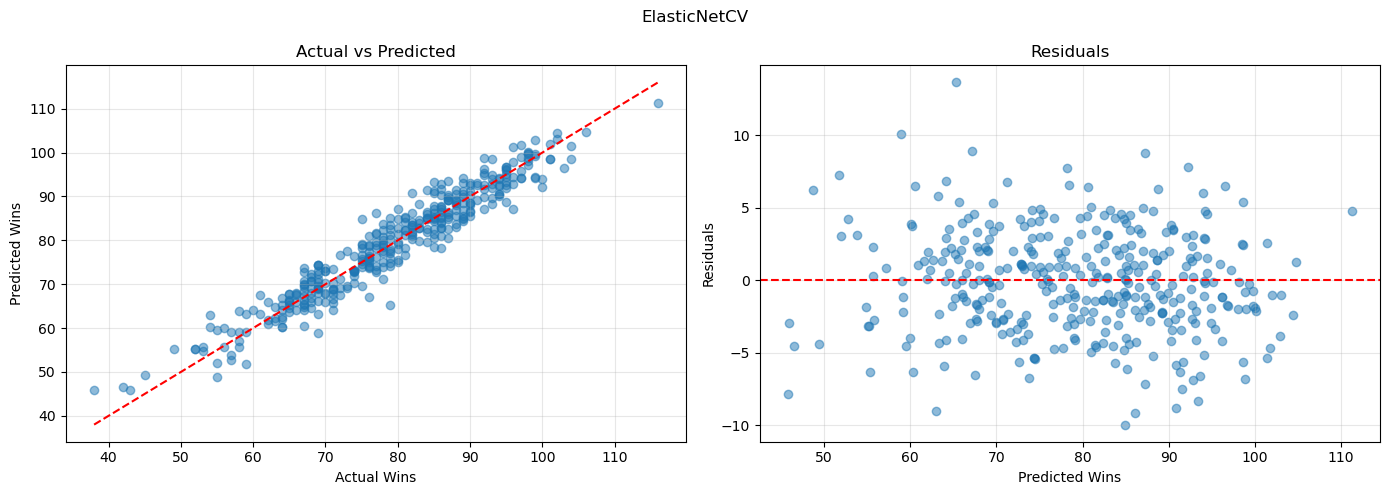

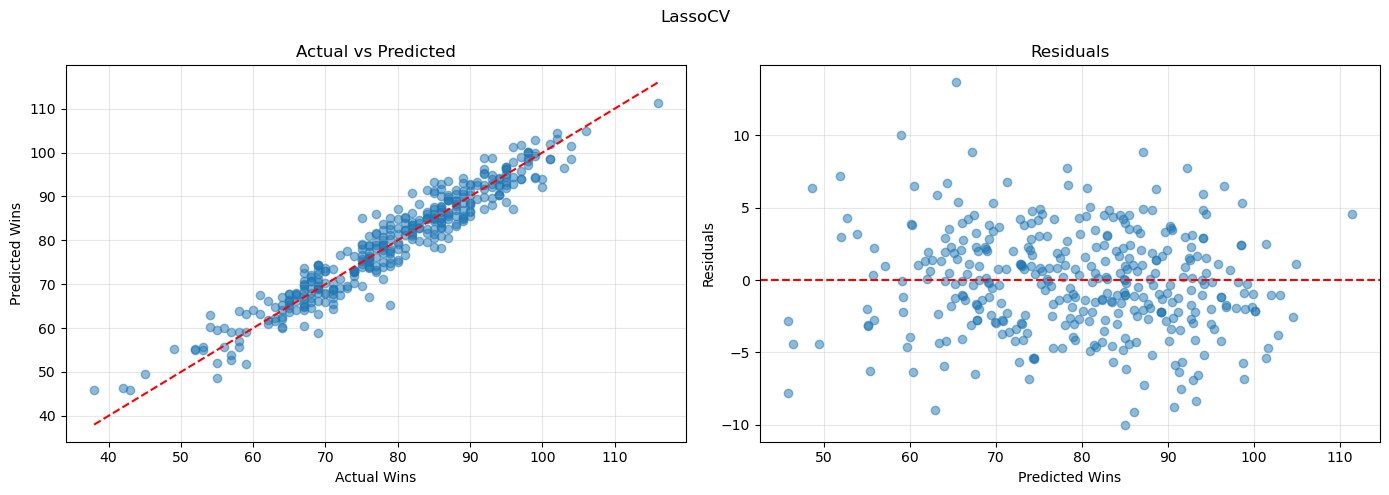

In [15]:
# ── Visualise Predictions ─────────────────────────────────────────────────────
def plot_model(model_name):
    """Actual-vs-predicted and residual plots for any registered model."""
    preds = models_registry[model_name]["test_preds"]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(model_name)

    axes[0].scatter(y_test, preds, alpha=0.5)
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
    axes[0].set(xlabel="Actual Wins", ylabel="Predicted Wins", title="Actual vs Predicted")
    axes[0].grid(True, alpha=0.3)

    residuals = y_test - preds
    axes[1].scatter(preds, residuals, alpha=0.5)
    axes[1].axhline(0, color="r", linestyle="--")
    axes[1].set(xlabel="Predicted Wins", ylabel="Residuals", title="Residuals")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


for name in models_registry:
    plot_model(name)